In [1]:
import matplotlib.pyplot as plt
import numpy as np

from block_encoding import generate_laplacian_block_encoding, get_circuit_unitary
from utils import prepare_v_vector, convert_vector_to_tensor
from camps_be import camps_block_encoding

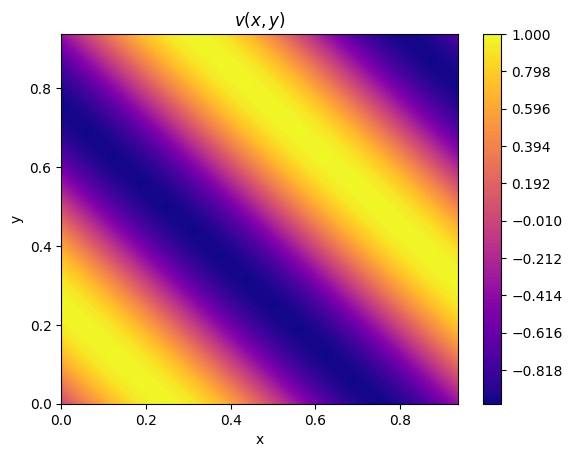

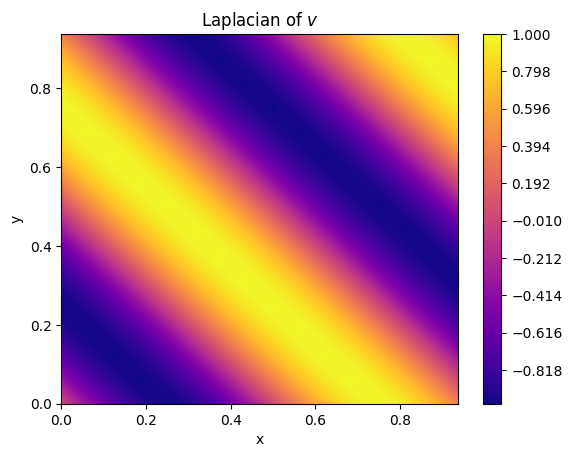

In [2]:
@np.vectorize
def v(x, y):
    return np.sin(2 * np.pi * (x + y))

def normalized_laplacian_2d(vmat):    
    left = np.roll(vmat, -1, axis=1)
    right = np.roll(vmat,  1, axis=1)
    up = np.roll(vmat, -1, axis=0)
    down = np.roll(vmat,  1, axis=0)
    
    lap = left + right + up + down - 4 * vmat
    
    return lap / np.max(np.abs(lap))



points_1d = np.linspace(0, 1, 2**4, endpoint=False)
points_2d = np.linspace(0, 1, 2**4, endpoint=False)
x, y = np.meshgrid(points_1d, points_2d)

plt.title("$v(x, y)$")
plt.xlabel("x")
plt.ylabel("y")
plt.contourf(x, y, v(x, y), levels=np.linspace(-1, 1, 100), cmap="plasma")
plt.colorbar()
plt.show()

plt.title("Laplacian of $v$")
plt.xlabel("x")
plt.ylabel("y")
plt.contourf(x, y, normalized_laplacian_2d(v(x, y)), levels=np.linspace(-1, 1, 100), cmap="plasma")
plt.colorbar()
plt.show()

In [3]:
nqs = range(1, 5)

be_success = []
camps_success = []

for nq in nqs:
    print(nq)
    v_vec = prepare_v_vector([nq, nq], v)

    # My code
    qc = generate_laplacian_block_encoding([nq, nq], bcs=["dirichlet", "dirichlet"], vs=v_vec)
    unitary = get_circuit_unitary(qc, [nq, nq])
    be_success.append(np.linalg.norm(unitary[:, 0]) ** 2)

    # Camps et al
    qc = camps_block_encoding(nq, ["dirichlet", "dirichlet"], vs=v_vec)
    unitary = get_circuit_unitary(qc, [nq, nq])
    camps_success.append(np.linalg.norm(unitary[:, 0]) ** 2)



1
2
3
4


/var/folders/tn/vkkzwdwn1cs5s6w9wqnpcz3c0000gn/T/ipykernel_32798/978998637.py:5: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  plt.plot(deltas, camps_success, "o", marker="v", label="Camps et al.")


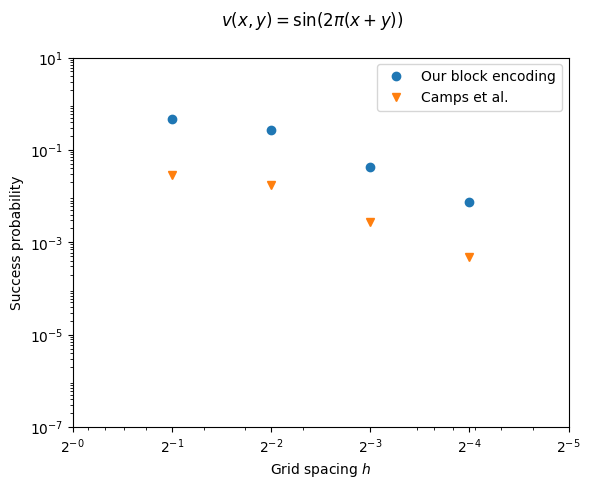

In [4]:
deltas = [2**-nq for nq in range(1, 5)]

plt.suptitle("$v(x, y) = \\sin(2 \\pi (x + y))$")
plt.plot(deltas, be_success, "o", label="Our block encoding")
plt.plot(deltas, camps_success, "o", marker="v", label="Camps et al.")
plt.xscale("log")
plt.yscale("log")
plt.gca().invert_xaxis()
plt.xticks([2**-i for i in range(0, 6)])
plt.yticks([10**i for i in range(-7, 2, 2)])
plt.gca().set_xticklabels([f"$2^{{-{i}}}$" for i in range(0, 6)])
plt.xlabel("Grid spacing $h$")
plt.ylabel("Success probability")
plt.legend()
plt.show()